In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from GP_regression_helpers import *

# Parameters
n_groups = 1
n_observations_per_group = 1000
n_dimensions = 5
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

n_new_dims = 5
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

100%|██████████| 1000/1000 [00:00<00:00, 1574.43it/s]


In [55]:
from pygrinder import mcar
# Normalize

p_dataset = .7

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
X = mcar(X_normalized.copy(), p_dataset)  # randomly hold out 10% observed values as ground truth
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

2025-02-24 15:32:51 [INFO]: No given device, using default device: cpu
2025-02-24 15:32:51 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-02-24 15:32:51 [INFO]: GP_VAE_posterior_concistency initialized with the given hyperparameters, the number of trainable parameters: 6,393


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=10, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=10, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=5, bias=True)
  )
)


2025-02-24 15:32:52 [INFO]: Epoch 001 - training loss: 8.0384, validation loss: 0.9734
2025-02-24 15:32:52 [INFO]: Epoch 002 - training loss: 7.9112, validation loss: 0.9683


-8.476487159729004 -5.922260761260986 0.047791704535484314 -2.5367798805236816


2025-02-24 15:32:53 [INFO]: Epoch 003 - training loss: 7.7825, validation loss: 0.9560


...

2025-02-24 15:33:27 [INFO]: Epoch 057 - training loss: 0.4158, validation loss: 0.5304
2025-02-24 15:33:28 [INFO]: Epoch 058 - training loss: 0.4014, validation loss: 0.5302
2025-02-24 15:33:29 [INFO]: Epoch 059 - training loss: 0.3895, validation loss: 0.5319
2025-02-24 15:33:30 [INFO]: Epoch 060 - training loss: 0.3745, validation loss: 0.5325
2025-02-24 15:33:30 [INFO]: Epoch 061 - training loss: 0.3619, validation loss: 0.5343
2025-02-24 15:33:31 [INFO]: Epoch 062 - training loss: 0.3470, validation loss: 0.5347


-0.19133998453617096 -0.14594817161560059 1.4431803226470947 0.04131677746772766
-0.19831258058547974 -0.16017641127109528 1.4817349910736084 0.042717382311820984


2025-02-24 15:33:32 [INFO]: Epoch 063 - training loss: 0.3309, validation loss: 0.5397
2025-02-24 15:33:32 [INFO]: Epoch 064 - training loss: 0.3183, validation loss: 0.5423
2025-02-24 15:33:32 [INFO]: Epoch 065 - training loss: 0.3037, validation loss: 0.5422
2025-02-24 15:33:33 [INFO]: Epoch 066 - training loss: 0.2909, validation loss: 0.5502
2025-02-24 15:33:34 [INFO]: Epoch 067 - training loss: 0.2773, validation loss: 0.5490
2025-02-24 15:33:34 [INFO]: Epoch 068 - training loss: 0.2634, validation loss: 0.5564


-0.14714199304580688 -0.11696745455265045 1.2368372678756714 0.05575520172715187


2025-02-24 15:33:35 [INFO]: Epoch 069 - training loss: 0.2496, validation loss: 0.5535
2025-02-24 15:33:36 [INFO]: Epoch 070 - training loss: 0.2359, validation loss: 0.5603
2025-02-24 15:33:36 [INFO]: Epoch 071 - training loss: 0.2243, validation loss: 0.5626
2025-02-24 15:33:37 [INFO]: Epoch 072 - training loss: 0.2146, validation loss: 0.5634
2025-02-24 15:33:38 [INFO]: Epoch 073 - training loss: 0.2061, validation loss: 0.5707
2025-02-24 15:33:38 [INFO]: Epoch 074 - training loss: 0.1960, validation loss: 0.5721
2025-02-24 15:33:39 [INFO]: Epoch 075 - training loss: 0.1904, validation loss: 0.5725
2025-02-24 15:33:39 [INFO]: Epoch 076 - training loss: 0.1836, validation loss: 0.5786
2025-02-24 15:33:40 [INFO]: Epoch 077 - training loss: 0.1783, validation loss: 0.5768
2025-02-24 15:33:41 [INFO]: Epoch 078 - training loss: 0.1741, validation loss: 0.5821
2025-02-24 15:33:42 [INFO]: Epoch 079 - training loss: 0.1696, validation loss: 0.5836
2025-02-24 15:33:43 [INFO]: Epoch 080 - tra

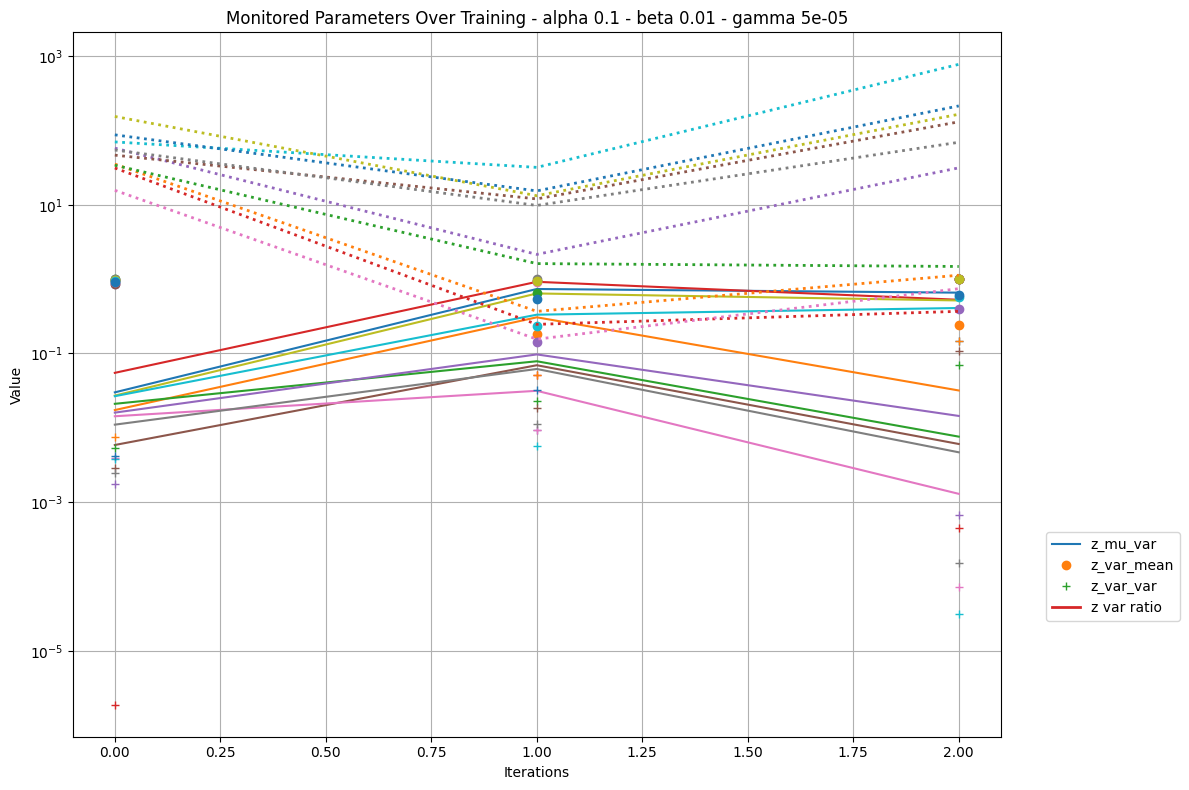

In [12]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE_posterior_concistency
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae_pc = GP_VAE_posterior_concistency(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = 10, 
            epochs = 200, 
            batch_size = 64,
            beta = 1., 
            K = 5,  
            encoder_sizes = (64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam(weight_decay=0.001) #lr = 1e-4
            )

gpvae_pc.model.backbone.alpha = 1e-1
gpvae_pc.model.backbone.beta = 1e-2
gpvae_pc.model.backbone.gamma = 5 * 1e-5
gpvae_pc.model.backbone.noise_sigma = 1e-3
gpvae_pc.model.backbone.sampling = False
gpvae_pc.model.backbone.use_mean = True
gpvae_pc.model.backbone.p = 0.3
gpvae_pc.model.backbone.detach = True


# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#with torch.autograd.set_detect_anomaly(False):
gpvae_pc.model.backbone.device = 'cpu'
gpvae_pc.fit(dataset_train, dataset_val)  # train the model on the dataset

In [4]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = 10, 
            epochs = 200, 
            batch_size = 64,
            beta = 1., 
            K = 5,  
            encoder_sizes = (64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam(weight_decay=0.001), #lr = 1e-4
            patience = 100
            )

gpvae.model.backbone.alpha = 1e0
gpvae.model.backbone.beta = 1e-2
gpvae.model.backbone.gamma = 5 * 1e-5
gpvae.model.backbone.noise_sigma = 1e-3
gpvae.model.backbone.sampling = True
gpvae.model.backbone.use_mean = True
gpvae.model.backbone.noise_std = 1e-2
gpvae.model.backbone.detach = True
gpvae.model.backbone.compensate = False


gpvae.model.backbone.p = 0.5
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/reformer/local_attention.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/reformer/local_attention.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
2025-02-24 15:27:23 [INFO]: No given device, using default device: cpu
2025-02-24 15:27:23 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-02-24 15:27:23 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 6,393



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 

Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=10, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=

2025-02-24 15:27:24 [INFO]: Epoch 001 - training loss: 469.6647, validation loss: 0.9701
2025-02-24 15:27:25 [INFO]: Epoch 002 - training loss: 462.4244, validation loss: 0.9667
2025-02-24 15:27:26 [INFO]: Epoch 003 - training loss: 450.0797, validation loss: 0.9500
2025-02-24 15:27:26 [INFO]: Epoch 004 - training loss: 400.4638, validation loss: 0.8921
2025-02-24 15:27:28 [INFO]: Epoch 005 - training loss: 274.3036, validation loss: 0.7525
2025-02-24 15:27:29 [INFO]: Epoch 006 - training loss: 186.4728, validation loss: 0.6976
2025-02-24 15:27:30 [INFO]: Epoch 007 - training loss: 152.8945, validation loss: 0.6766
2025-02-24 15:27:30 [INFO]: Epoch 008 - training loss: 132.4610, validation loss: 0.6385
2025-02-24 15:27:31 [INFO]: Epoch 009 - training loss: 116.0998, validation loss: 0.6123
2025-02-24 15:27:32 [INFO]: Epoch 010 - training loss: 100.8801, validation loss: 0.5808
2025-02-24 15:27:33 [INFO]: Epoch 011 - training loss: 88.9062, validation loss: 0.5566
2025-02-24 15:27:34 [I

Plotting latent series and reconstruction...


2025-02-24 15:28:27 [INFO]: Epoch 073 - training loss: 15.3989, validation loss: 0.3672
2025-02-24 15:28:28 [INFO]: Epoch 074 - training loss: 15.1045, validation loss: 0.3652
2025-02-24 15:28:28 [INFO]: Epoch 075 - training loss: 14.7967, validation loss: 0.3647
2025-02-24 15:28:29 [INFO]: Epoch 076 - training loss: 14.4801, validation loss: 0.3653
2025-02-24 15:28:30 [INFO]: Epoch 077 - training loss: 14.1437, validation loss: 0.3651
2025-02-24 15:28:31 [INFO]: Epoch 078 - training loss: 13.9602, validation loss: 0.3660
2025-02-24 15:28:32 [INFO]: Epoch 079 - training loss: 13.6912, validation loss: 0.3684
2025-02-24 15:28:33 [INFO]: Epoch 080 - training loss: 13.4395, validation loss: 0.3677
2025-02-24 15:28:33 [INFO]: Epoch 081 - training loss: 13.1714, validation loss: 0.3699
2025-02-24 15:28:35 [INFO]: Epoch 082 - training loss: 12.8871, validation loss: 0.3713
2025-02-24 15:28:36 [INFO]: Epoch 083 - training loss: 12.6838, validation loss: 0.3718
2025-02-24 15:28:36 [INFO]: Epoc

In [56]:
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

2025-02-24 17:13:35 [INFO]: Epoch 001 - training loss: 9.7421, validation loss: 0.4050
2025-02-24 17:13:35 [INFO]: Epoch 002 - training loss: 9.0306, validation loss: 0.4017
2025-02-24 17:13:36 [INFO]: Epoch 003 - training loss: 8.8060, validation loss: 0.4080
2025-02-24 17:13:37 [INFO]: Epoch 004 - training loss: 8.6580, validation loss: 0.4091
2025-02-24 17:13:38 [INFO]: Epoch 005 - training loss: 8.5489, validation loss: 0.4104
2025-02-24 17:13:39 [INFO]: Epoch 006 - training loss: 8.5035, validation loss: 0.4084
2025-02-24 17:13:40 [INFO]: Epoch 007 - training loss: 8.5087, validation loss: 0.4110
2025-02-24 17:13:41 [INFO]: Epoch 008 - training loss: 8.4410, validation loss: 0.4123
2025-02-24 17:13:41 [INFO]: Epoch 009 - training loss: 8.3568, validation loss: 0.4115
2025-02-24 17:13:43 [INFO]: Epoch 010 - training loss: 8.3531, validation loss: 0.4136
2025-02-24 17:13:43 [INFO]: Epoch 011 - training loss: 8.2831, validation loss: 0.4156
2025-02-24 17:13:44 [INFO]: Epoch 012 - tra

Plotting latent series and reconstruction...


2025-02-24 17:13:47 [INFO]: Epoch 015 - training loss: 8.2100, validation loss: 0.4159
2025-02-24 17:13:48 [INFO]: Epoch 016 - training loss: 8.1776, validation loss: 0.4170
2025-02-24 17:13:49 [INFO]: Epoch 017 - training loss: 8.1618, validation loss: 0.4160
2025-02-24 17:13:50 [INFO]: Epoch 018 - training loss: 8.1517, validation loss: 0.4165
2025-02-24 17:13:51 [INFO]: Epoch 019 - training loss: 8.1305, validation loss: 0.4200
2025-02-24 17:13:51 [INFO]: Epoch 020 - training loss: 8.1412, validation loss: 0.4220
2025-02-24 17:13:52 [INFO]: Epoch 021 - training loss: 8.0974, validation loss: 0.4203
2025-02-24 17:13:53 [INFO]: Epoch 022 - training loss: 8.0707, validation loss: 0.4209
2025-02-24 17:13:54 [INFO]: Epoch 023 - training loss: 8.0346, validation loss: 0.4222
2025-02-24 17:13:55 [INFO]: Epoch 024 - training loss: 8.0714, validation loss: 0.4224
2025-02-24 17:13:56 [INFO]: Epoch 025 - training loss: 8.0649, validation loss: 0.4250
2025-02-24 17:13:56 [INFO]: Epoch 026 - tra

In [40]:
def plot_reconstruction(X, X_true, gpae):
    """
    plot reconstruction of X and ground truth X_true
    """

    X_torch = torch.tensor(X).float()
    embedding = gpvae_pc.model.backbone.encode(X_torch)

    z_samples = embedding.rsample((100,))

    print(z_samples.shape)

    X_recon = gpae.model.backbone.decode(z_samples).mean.detach()

    X_recon_mean = X_recon.mean(axis=0)
    X_recon_min, X_recon_max = X_recon.min(axis=0).values, X_recon.max(axis=0).values

    i = 2
    X_torch[X_torch==0] = torch.nan
    plt.gca().set_prop_cycle(None)
    plt.plot(X_recon_mean[i].detach(), label = 'recon')
    for j in range(X_recon_mean.shape[-1]):
        plt.fill_between(np.arange(30), X_recon_min[i,:,j], X_recon_max[i,:,j], alpha = .2)
    plt.gca().set_prop_cycle(None)
    plt.plot(X_torch[i].detach(), 'o');
    plt.gca().set_prop_cycle(None)
    plt.plot(X_true[i], '+');

def plot_reconstruction_with_GP(X, X_true, gpae):

    
    # Example usage
    X[X!=X] = 0.
    kernel_params = gpvae_pc.gp.update_kernel_params(torch.tensor(X).float())
    x_input, x_recon_mean, x_recon_min, x_recon_max = reconstruct_with_given_kernel_params(
        X, kernel_params, gpvae_pc, return_variance = True
    )

    i = 1
    x_input[x_input==0] = np.nan
    plt.plot(x_input[i].detach(),'o');
    plt.gca().set_prop_cycle(None);
    plt.plot(x_recon_mean[i].detach());
    plt.gca().set_prop_cycle(None);
    for j in range(x_recon_mean.shape[2]):
        plt.fill_between(np.arange(30),
                        x_recon_min[i,:,j].detach(),
                        x_recon_max[i,:,j].detach(),
                        alpha = .2)
    plt.plot(X_true[i],'+')
    plt.ylim([-4,4]);

    MSE = (X_true - x_recon_mean.detach().numpy())**2

    mask_observed = (X!=0)
    mask_hidden = (X_true!=0)&(~mask_observed)
    MSE_observed = MSE[mask_observed].mean()
    MSE_hidden = MSE[mask_hidden].mean()

    return MSE_observed, MSE_hidden


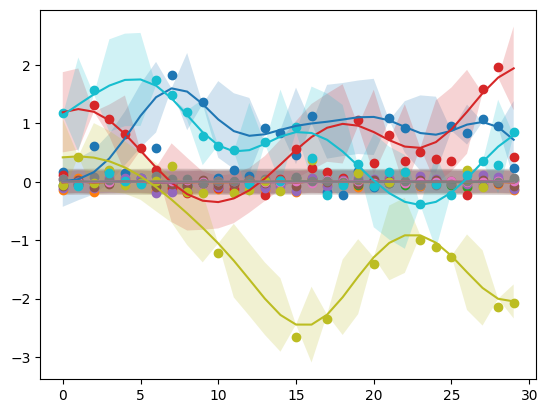

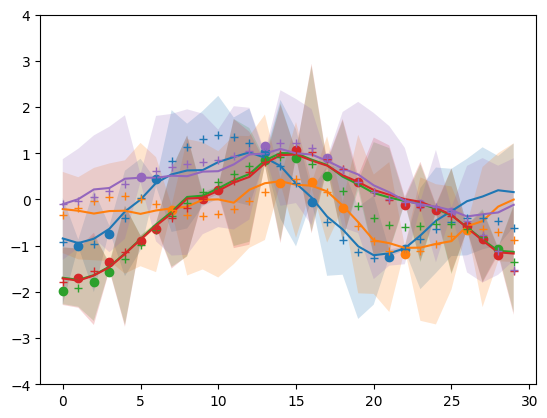

In [57]:
mse_obs_pc, mse_hidden_pc = plot_reconstruction_with_GP(X[::5], X_normalized[::5], gpvae_pc)

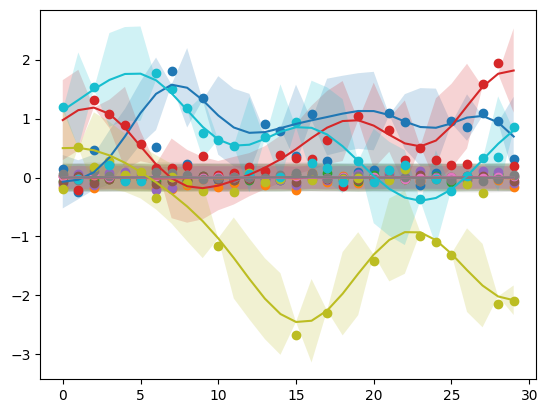

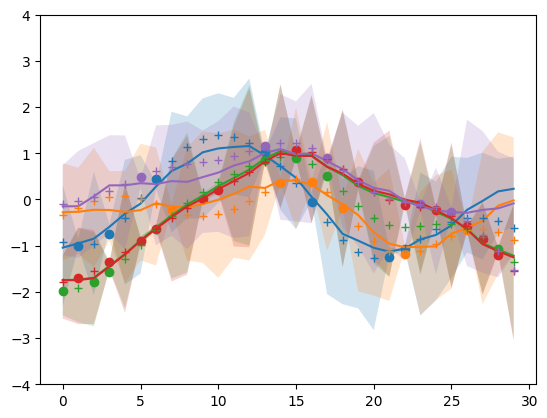

In [58]:
mse_obs, mse_hidden = plot_reconstruction_with_GP(X[::5], X_normalized[::5], gpvae)

In [59]:
print(mse_obs, mse_obs_pc)
print(mse_hidden, mse_hidden_pc)

0.011568267232540869 0.011496430523967014
0.1412408816570718 0.13898574084703277


fitting kernel


Epoch 1/20: 0it [00:00, ?it/s]

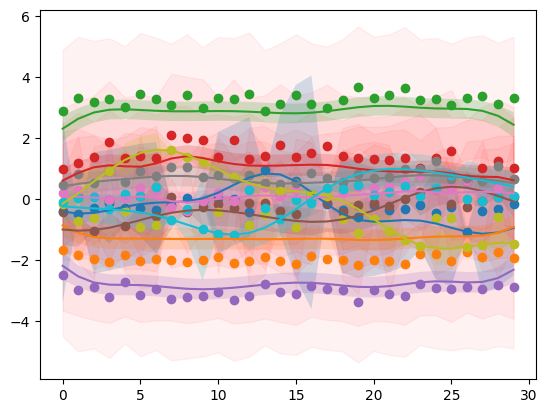

Epoch 1/20: 11it [00:03,  2.93it/s]


Epoch 1/20: Average Loss = 0.037005


Epoch 2/20: 0it [00:00, ?it/s]

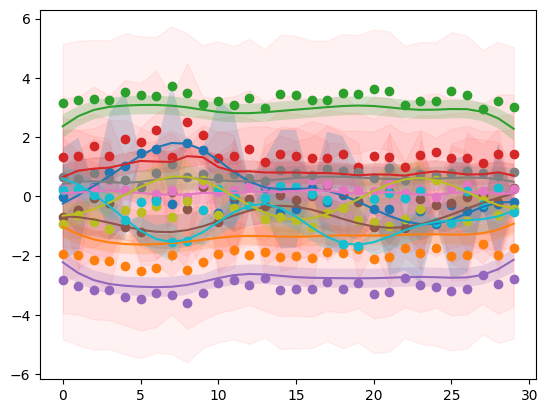

Epoch 2/20: 11it [00:03,  3.13it/s]


Epoch 2/20: Average Loss = 0.039343


Epoch 3/20: 0it [00:00, ?it/s]

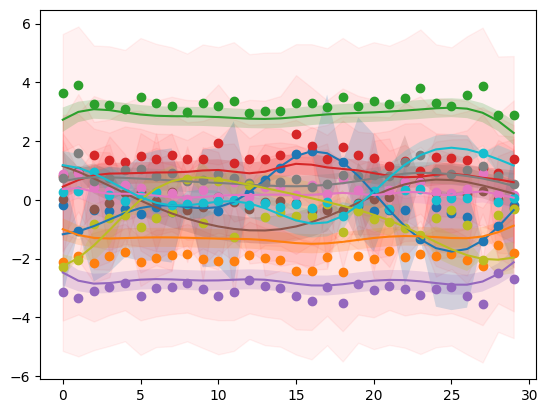

Epoch 3/20: 11it [00:03,  3.02it/s]


Epoch 3/20: Average Loss = 0.039927


Epoch 4/20: 0it [00:00, ?it/s]

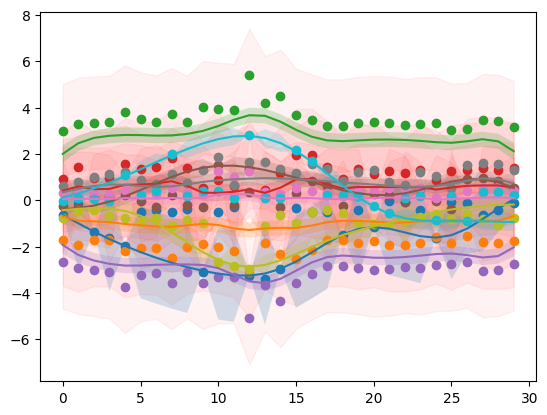

Epoch 4/20: 11it [00:03,  3.09it/s]


Epoch 4/20: Average Loss = 0.037669


Epoch 5/20: 0it [00:00, ?it/s]

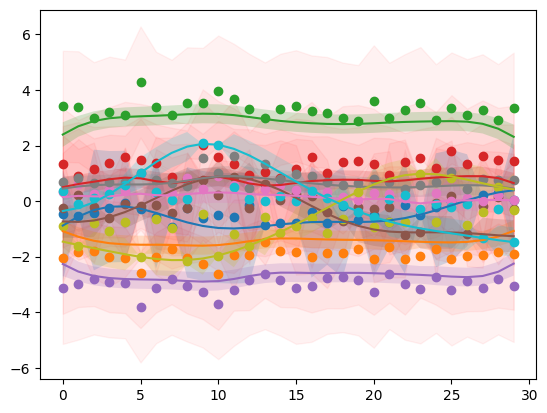

Epoch 5/20: 11it [00:03,  3.20it/s]


Epoch 5/20: Average Loss = 0.038635


Epoch 6/20: 0it [00:00, ?it/s]

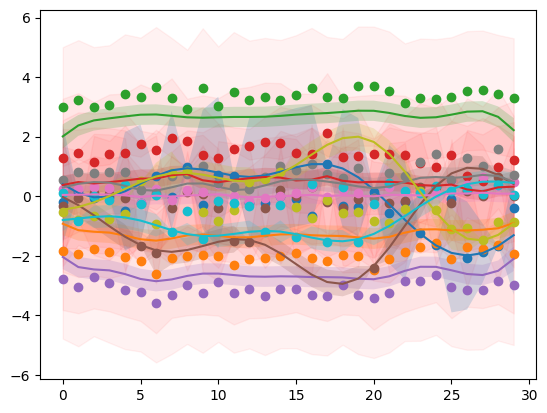

Epoch 6/20: 11it [00:03,  3.09it/s]


Epoch 6/20: Average Loss = 0.038338


Epoch 7/20: 0it [00:00, ?it/s]

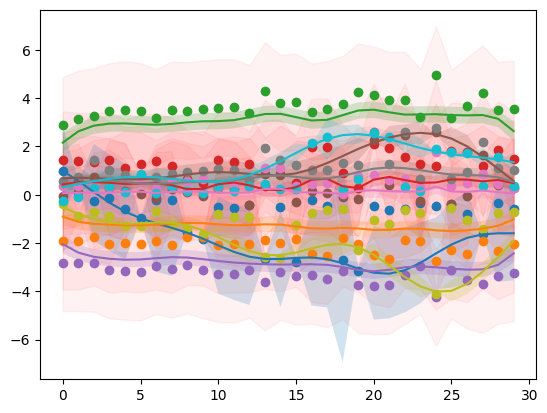

Epoch 7/20: 11it [00:03,  3.24it/s]


Epoch 7/20: Average Loss = 0.037053


Epoch 8/20: 0it [00:00, ?it/s]

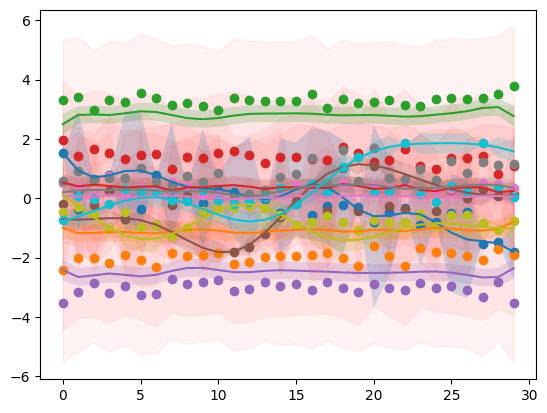

Epoch 8/20: 10it [00:03,  2.99it/s]


KeyboardInterrupt: 

In [60]:
gpvae.fit_kernel(dataset_train, dataset_val)  # train the model on the dataset

In [48]:
torch.save(gpvae_pc.model.backbone.encoder.state_dict().copy(), 'encoder')
torch.save(gpvae_pc.model.backbone.decoder.state_dict().copy(), 'decoder')

In [49]:
state_dict = torch.load('encoder');
gpvae_pc.model.backbone.encoder.load_state_dict(state_dict);
state_dict = torch.load('decoder');
gpvae_pc.model.backbone.decoder.load_state_dict(state_dict);

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_66525/3524024195.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('encoder');
/var/fold

In [ ]:
torch.save(gpvae_pc.gp.kernel_params_estimator.state_dict().copy(), 'gp_init')

In [ ]:
state_dict = torch.load('gp_init')
gpvae_pc.gp.kernel_params_estimator.load_state_dict(state_dict);

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_61966/393264467.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('gp_init')


2025-02-24 15:14:54 [INFO]: Epoch 001 - training loss: 0.2184, validation loss: 0.4311
2025-02-24 15:14:54 [INFO]: Epoch 002 - training loss: 0.2184, validation loss: 0.4313
2025-02-24 15:14:55 [INFO]: Epoch 003 - training loss: 0.2175, validation loss: 0.4325
2025-02-24 15:14:55 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-02-24 15:14:55 [INFO]: Finished training. The best model is from epoch#1.


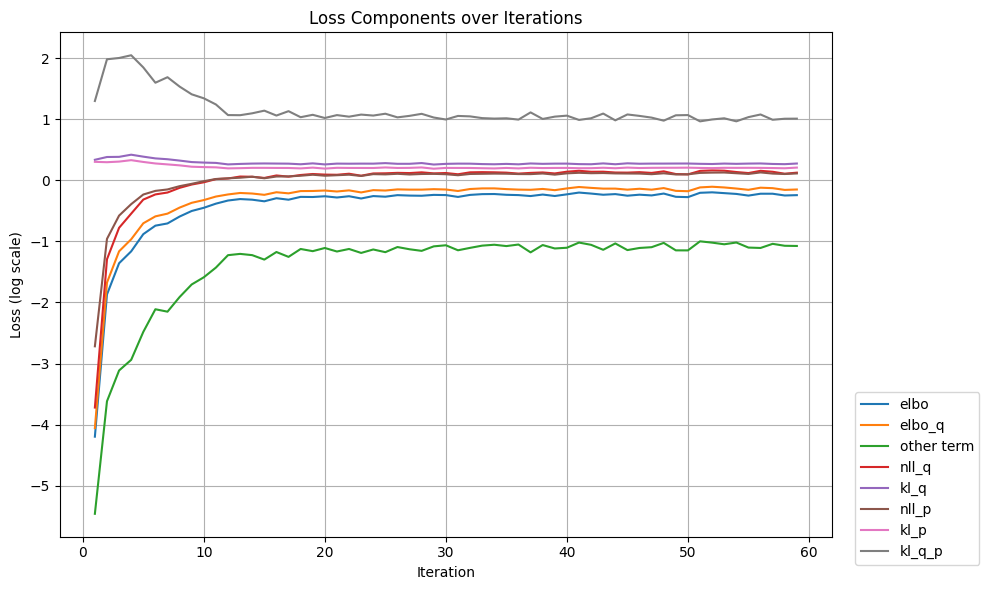

In [50]:
gpvae_pc.fit(dataset_train, dataset_val)  # train the model on the dataset

fitting kernel


Epoch 1/20: 0it [00:00, ?it/s]

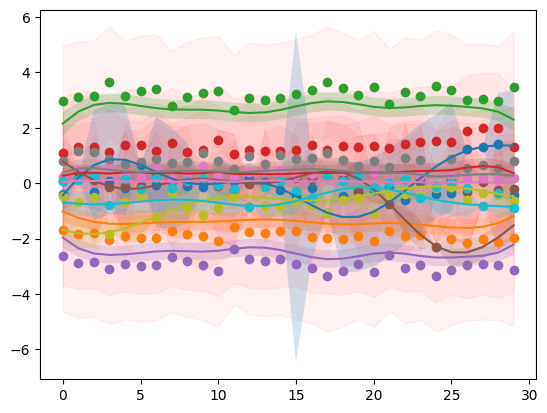

Epoch 1/20: 11it [00:03,  3.10it/s]


Epoch 1/20: Average Loss = 0.038137


Epoch 2/20: 0it [00:00, ?it/s]

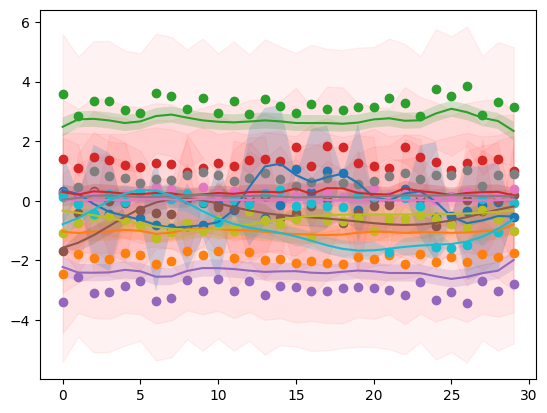

Epoch 2/20: 11it [00:03,  3.06it/s]


Epoch 2/20: Average Loss = 0.035502


Epoch 3/20: 0it [00:00, ?it/s]

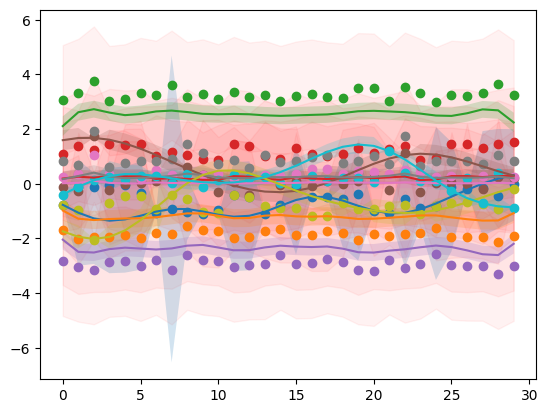

Epoch 3/20: 11it [00:03,  3.09it/s]


Epoch 3/20: Average Loss = 0.038042


Epoch 4/20: 0it [00:00, ?it/s]

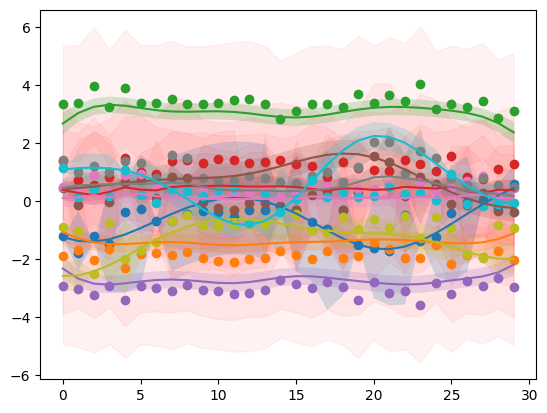

Epoch 4/20: 11it [00:03,  2.99it/s]


Epoch 4/20: Average Loss = 0.037644


Epoch 5/20: 0it [00:00, ?it/s]

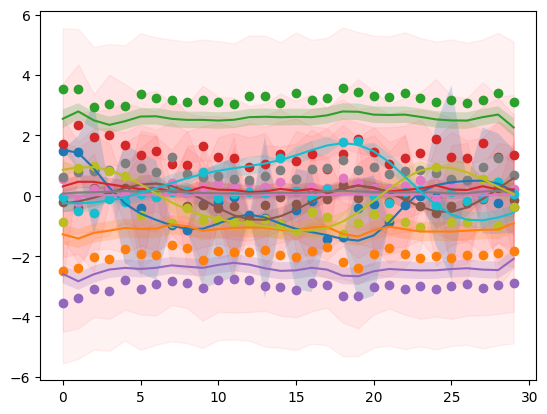

Epoch 5/20: 11it [00:03,  3.18it/s]


Epoch 5/20: Average Loss = 0.036093


Epoch 6/20: 0it [00:00, ?it/s]

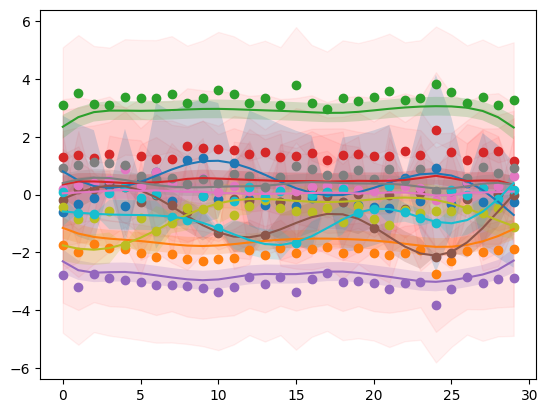

Epoch 6/20: 11it [00:03,  3.09it/s]


Epoch 6/20: Average Loss = 0.035115


Epoch 7/20: 0it [00:00, ?it/s]

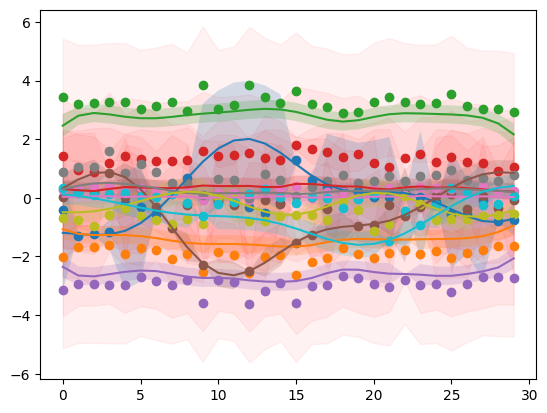

Epoch 7/20: 11it [00:03,  2.96it/s]


Epoch 7/20: Average Loss = 0.036552


Epoch 8/20: 0it [00:00, ?it/s]

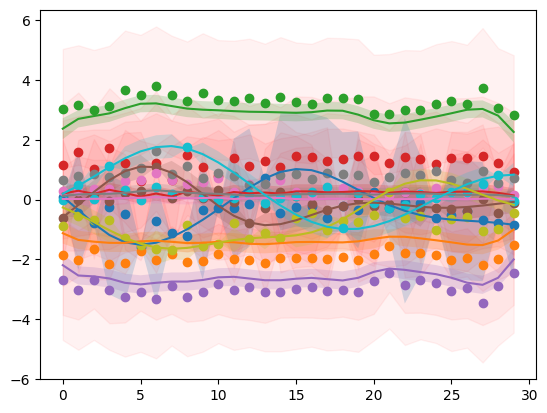

Epoch 8/20: 11it [00:03,  3.13it/s]


Epoch 8/20: Average Loss = 0.037145


Epoch 9/20: 0it [00:00, ?it/s]

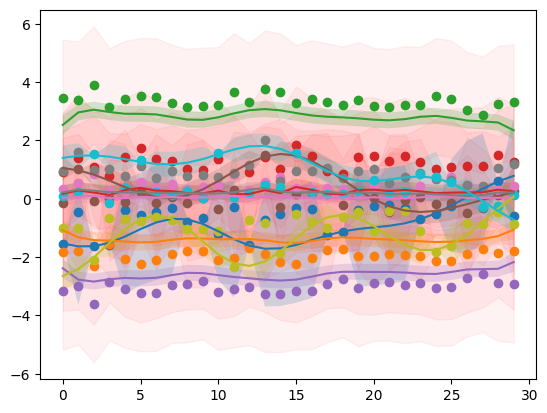

Epoch 9/20: 11it [00:03,  3.04it/s]


Epoch 9/20: Average Loss = 0.036913


Epoch 10/20: 0it [00:00, ?it/s]

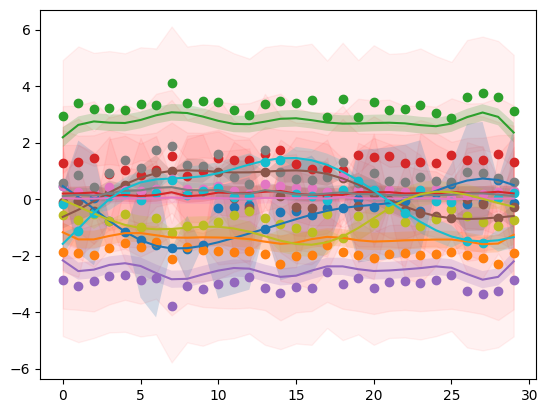

Epoch 10/20: 3it [00:01,  2.98it/s]

In [64]:
gpvae.fit_kernel(dataset_train, dataset_val)  # train the model on the dataset

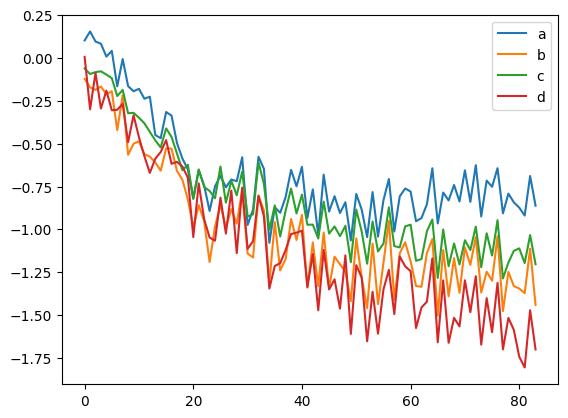

In [63]:
for key in gpvae_pc.gp.kernel_params_history.keys():
    plt.plot(gpvae.gp.kernel_params_history[key], label = key)
plt.legend();

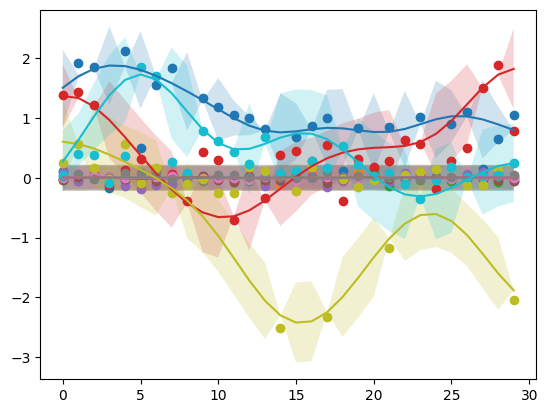

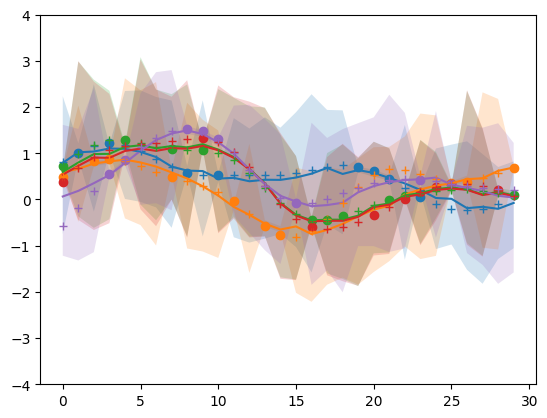

In [16]:

# Example usage
X[X!=X] = 0.
kernel_params = gpvae_pc.gp.update_kernel_params(torch.tensor(X[:10]).float())
x_input, x_recon_mean, x_recon_min, x_recon_max = reconstruct_with_given_kernel_params(
    X[:10], kernel_params, gpvae_pc, return_variance = True
)

i = 1
x_input[x_input==0] = np.nan
plt.plot(x_input[i].detach(),'o');
plt.gca().set_prop_cycle(None);
plt.plot(x_recon_mean[i].detach());
plt.gca().set_prop_cycle(None);
for j in range(x_recon_mean.shape[2]):
    plt.fill_between(np.arange(30),
                    x_recon_min[i,:,j].detach(),
                    x_recon_max[i,:,j].detach(),
                    alpha = .2)
plt.plot(X_normalized[i],'+')
plt.ylim([-4,4]);
